# SAR Threshold Comparison: -12 dB vs -18 dB
## SAR 閾值比較：-12 dB vs -18 dB

**Objective**: Compare different SAR backscatter thresholds for flood detection
**目標**: 比較不同 SAR 後向散射閾值對淹水偵測的影響

Based on Week10-Student.ipynb cells 3-10 methodology
基於 Week10-Student.ipynb cells 3-10 方法論

In [1]:
# Environment Setup (same as Week10 Cell 2)
# ──────────────────────────────────────────────────────────────────
import os, time, warnings
warnings.filterwarnings('ignore')

# GDAL HTTP retry settings
os.environ.setdefault('GDAL_HTTP_MAX_RETRY', '5')
os.environ.setdefault('GDAL_HTTP_RETRY_DELAY', '2')
os.environ.setdefault('GDAL_HTTP_TIMEOUT', '60')
os.environ.setdefault('GDAL_HTTP_MULTIRANGE', 'YES')
os.environ.setdefault('GDAL_HTTP_MERGE_CONSECUTIVE_RANGES', 'YES')
os.environ.setdefault('VSI_CACHE', 'TRUE')
os.environ.setdefault('VSI_CACHE_SIZE', '1000000000')
os.environ.setdefault('CPL_VSIL_CURL_ALLOWED_EXTENSIONS', '.tif,.TIF,.tiff')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import median_filter, binary_opening, label
import xarray as xr
import rioxarray as rxr
import pystac_client
import planetary_computer as pc
import stackstac

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang TC', 'Heiti TC', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# Initialize STAC catalog
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=pc.sign_inplace,
)

# Study area bbox (same as Week10)
LAKE_BBOX = [121.270, 23.685, 121.310, 23.715]

# Output directory
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Environment setup complete')

✅ Environment setup complete


In [2]:
# SAR Search Function (same as Week10 Cell 3)
# ──────────────────────────────────────────────────────────────────
def search_sar(bbox, datetime_range, orbit_state=None, max_items=30, tries=3):
    """Search sentinel-1-rtc with retry + orbit filtering."""
    last_err = None
    for attempt in range(tries):
        try:
            search = catalog.search(
                collections=['sentinel-1-rtc'],
                bbox=bbox,
                datetime=datetime_range,
                max_items=max_items,
            )
            items = list(search.items())
            if orbit_state:
                items = [i for i in items
                         if i.properties.get('sat:orbit_state', '').lower() == orbit_state.lower()]
            items.sort(key=lambda i: i.properties.get('datetime', ''))
            return items
        except Exception as e:
            last_err = e
            time.sleep(2 ** attempt)
    raise RuntimeError(f'STAC search failed: {last_err}')

def safe_compute(lazy_arr, tries=4):
    """Retry wrapper for COG reads."""
    from rasterio.errors import RasterioIOError
    last_err = None
    for attempt in range(tries):
        try:
            return lazy_arr.compute()
        except RasterioIOError as e:
            last_err = e
            time.sleep(2 ** attempt)
    raise RuntimeError(f'Compute failed: {last_err}')

print('✅ SAR search functions ready')

✅ SAR search functions ready


In [3]:
# Search for SAR Data (same as Week10 Cell 3)
# ──────────────────────────────────────────────────────────────────
# Search pre and post disaster scenes
all_pre  = search_sar(LAKE_BBOX, '2025-06-15/2025-07-17')
all_post = search_sar(LAKE_BBOX, '2025-09-10/2025-09-25')

print(f'Pre-disaster: {len(all_pre)} scenes')
for it in all_pre:
    p = it.properties
    print(f"  {p.get('datetime','?')[:16]} | {p.get('sat:orbit_state','?')} | {it.id[:40]}")

print(f'\nPost-disaster: {len(all_post)} scenes')
for it in all_post:
    p = it.properties
    print(f"  {p.get('datetime','?')[:16]} | {p.get('sat:orbit_state','?')} | {it.id[:40]}")

# Select common orbit
orbits_pre  = set(i.properties.get('sat:orbit_state','').lower() for i in all_pre)
orbits_post = set(i.properties.get('sat:orbit_state','').lower() for i in all_post)
common = orbits_pre & orbits_post
print(f'\n共同軌道: {common}')

if 'ascending' in common:
    ORBIT_STATE = 'ascending'
elif 'descending' in common:
    ORBIT_STATE = 'descending'
elif common:
    ORBIT_STATE = list(common)[0]
else:
    ORBIT_STATE = list(orbits_post)[0] if orbits_post else None
    print(f'⚠ 沒有共同軌道！使用 {ORBIT_STATE}')

print(f'→ 選定: {ORBIT_STATE}')

items_pre  = [i for i in all_pre  if i.properties.get('sat:orbit_state','').lower() == ORBIT_STATE]
items_post = [i for i in all_post if i.properties.get('sat:orbit_state','').lower() == ORBIT_STATE]
print(f'PRE ({ORBIT_STATE}): {len(items_pre)} | POST ({ORBIT_STATE}): {len(items_post)}')

Pre-disaster: 7 scenes
  2025-06-16T21:53 | descending | S1A_IW_GRDH_1SDV_20250616T215252_2025061
  2025-06-22T21:51 | descending | S1C_IW_GRDH_1SDV_20250622T215146_2025062
  2025-06-26T10:01 | ascending | S1A_IW_GRDH_1SDV_20250626T100124_2025062
  2025-06-28T21:53 | descending | S1A_IW_GRDH_1SDV_20250628T215251_2025062
  2025-07-04T21:51 | descending | S1C_IW_GRDH_1SDV_20250704T215147_2025070
  2025-07-10T21:53 | descending | S1A_IW_GRDH_1SDV_20250710T215251_2025071
  2025-07-16T21:52 | descending | S1C_IW_GRDH_1SDV_20250716T215148_2025071

Post-disaster: 3 scenes
  2025-09-14T21:52 | descending | S1C_IW_GRDH_1SDV_20250914T215150_2025091
  2025-09-18T10:01 | ascending | S1A_IW_GRDH_1SDV_20250918T100123_2025091
  2025-09-20T21:53 | descending | S1A_IW_GRDH_1SDV_20250920T215251_2025092

共同軌道: {'descending', 'ascending'}
→ 選定: ascending
PRE (ascending): 1 | POST (ascending): 1


In [4]:
# SAR Streaming Function (same as Week10 Cell 4)
# ──────────────────────────────────────────────────────────────────
def stream_sar(item, bands=['vv'], bbox=LAKE_BBOX):
    """Stream Sentinel-1 GRD as lazy xarray (linear backscatter)."""
    signed = pc.sign(item)
    cube = stackstac.stack(
        [signed],
        assets=bands,
        epsg=32651,          # UTM 51N
        resolution=10,
        bounds_latlon=bbox,
        chunksize=2048,
    ).squeeze('time')
    return cube

print('✅ stream_sar() ready')

✅ stream_sar() ready


In [5]:
# Load SAR Data and Convert to dB (same as Week10 Cell 5)
# ──────────────────────────────────────────────────────────────────
if not items_pre or not items_post:
    raise ValueError('災前或災後無場景！')

pre_item = items_pre[0]
post_item = items_post[0]
print(f'PRE:  {pre_item.properties["datetime"][:16]} | {pre_item.properties.get("sat:orbit_state","?")}')
print(f'POST: {post_item.properties["datetime"][:16]} | {post_item.properties.get("sat:orbit_state","?")}')

# Confirm orbit match
orb_pre = pre_item.properties.get('sat:orbit_state', '')
orb_post = post_item.properties.get('sat:orbit_state', '')
if orb_pre.lower() != orb_post.lower():
    print(f'⚠ WARNING: orbit mismatch! {orb_pre} vs {orb_post}')
else:
    print(f'✅ Orbit match: both {orb_post}')

# Load post-disaster VV (for flood detection)
print('\nLoading post-disaster VV...')
vv_post_linear = safe_compute(stream_sar(post_item, ['vv']))
vv_post_db = 10 * np.log10(vv_post_linear.values.squeeze().astype(np.float32))
vv_post_db = np.where(np.isfinite(vv_post_db), vv_post_db, np.nan)

print(f'Post shape: {vv_post_db.shape}, range: {np.nanmin(vv_post_db):.1f} ~ {np.nanmax(vv_post_db):.1f} dB')
print('✅ SAR data loaded')

PRE:  2025-06-26T10:01 | ascending
POST: 2025-09-18T10:01 | ascending
✅ Orbit match: both ascending

Loading post-disaster VV...
Post shape: (338, 413), range: -28.0 ~ 11.8 dB
✅ SAR data loaded


In [6]:
# Apply Different Thresholds: -12 dB vs -18 dB
# ──────────────────────────────────────────────────────────────────
# Define thresholds
THRESHOLD_LOOSE = -12  # -12 dB (loose)
THRESHOLD_STRICT = -18  # -18 dB (strict)

# Apply speckle filtering (same as Week10 Cell 8)
sar_filtered = median_filter(vv_post_db, size=5)

# Apply thresholds without morphological cleaning (for pure comparison)
mask_loose = (sar_filtered < THRESHOLD_LOOSE).astype(np.uint8)
mask_strict = (sar_filtered < THRESHOLD_STRICT).astype(np.uint8)

# Calculate pixel counts and areas
px_area_ha = (10 * 10) / 10000  # hectares per pixel

loose_count = np.sum(mask_loose)
strict_count = np.sum(mask_strict)

loose_area = loose_count * px_area_ha
strict_area = strict_count * px_area_ha

print(f'Threshold -12 dB: {loose_count:,} px = {loose_area:.1f} ha')
print(f'Threshold -18 dB: {strict_count:,} px = {strict_area:.1f} ha')
print(f'Difference: {loose_count - strict_count:,} px = {(loose_count - strict_count) * px_area_ha:.1f} ha')
print(f'NCDR measured area ~80 ha')

Threshold -12 dB: 26,211 px = 262.1 ha
Threshold -18 dB: 6,195 px = 62.0 ha
Difference: 20,016 px = 200.2 ha
NCDR measured area ~80 ha


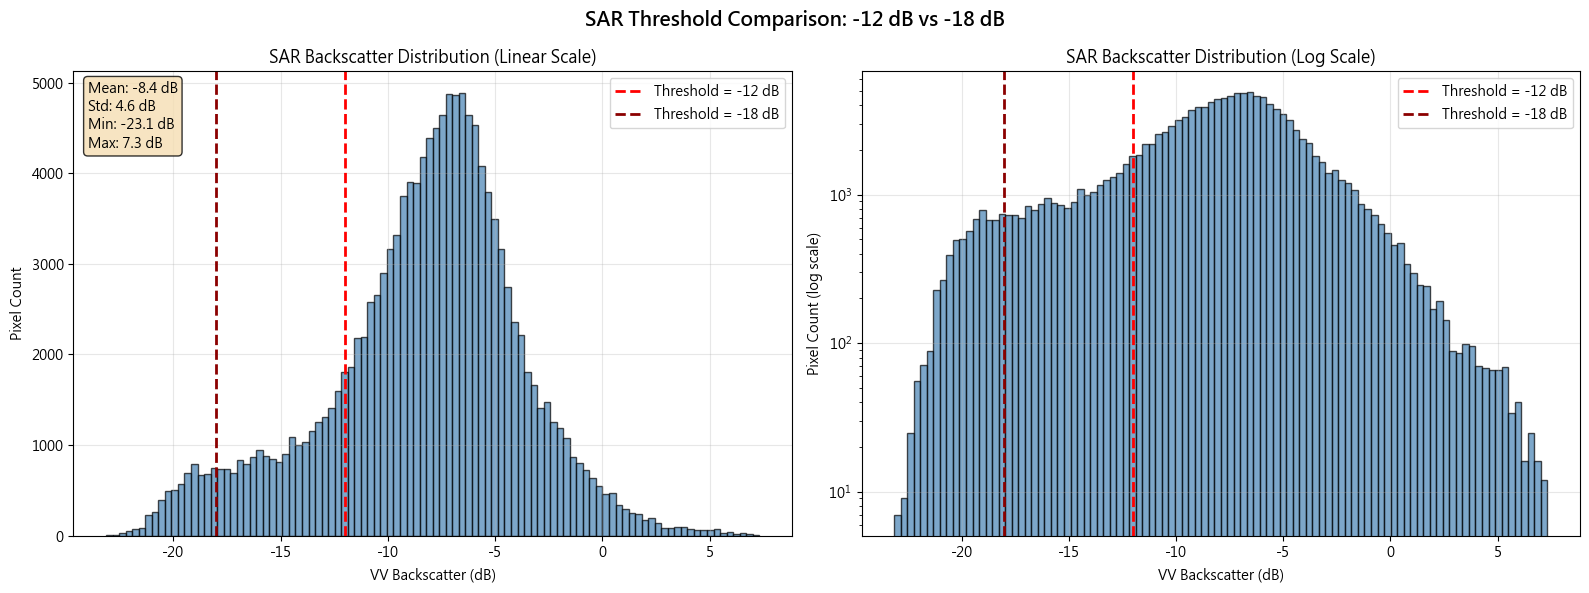

In [7]:
# Generate Histogram Comparison: Log Pixel Count vs dB
# ──────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Remove NaN values for histogram
valid_pixels = sar_filtered[np.isfinite(sar_filtered)]

# Histogram 1: Linear scale
counts, bins, patches = ax1.hist(valid_pixels, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(THRESHOLD_LOOSE, color='red', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD_LOOSE} dB')
ax1.axvline(THRESHOLD_STRICT, color='darkred', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD_STRICT} dB')
ax1.set_xlabel('VV Backscatter (dB)')
ax1.set_ylabel('Pixel Count')
ax1.set_title('SAR Backscatter Distribution (Linear Scale)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram 2: Log scale (as requested)
ax2.hist(valid_pixels, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
ax2.axvline(THRESHOLD_LOOSE, color='red', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD_LOOSE} dB')
ax2.axvline(THRESHOLD_STRICT, color='darkred', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD_STRICT} dB')
ax2.set_xlabel('VV Backscatter (dB)')
ax2.set_ylabel('Pixel Count (log scale)')
ax2.set_title('SAR Backscatter Distribution (Log Scale)')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add statistics text
stats_text = f'Mean: {np.nanmean(valid_pixels):.1f} dB\nStd: {np.nanstd(valid_pixels):.1f} dB\nMin: {np.nanmin(valid_pixels):.1f} dB\nMax: {np.nanmax(valid_pixels):.1f} dB'
ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, fontsize=10,
          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('SAR Threshold Comparison: -12 dB vs -18 dB', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/SAR_histogram_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

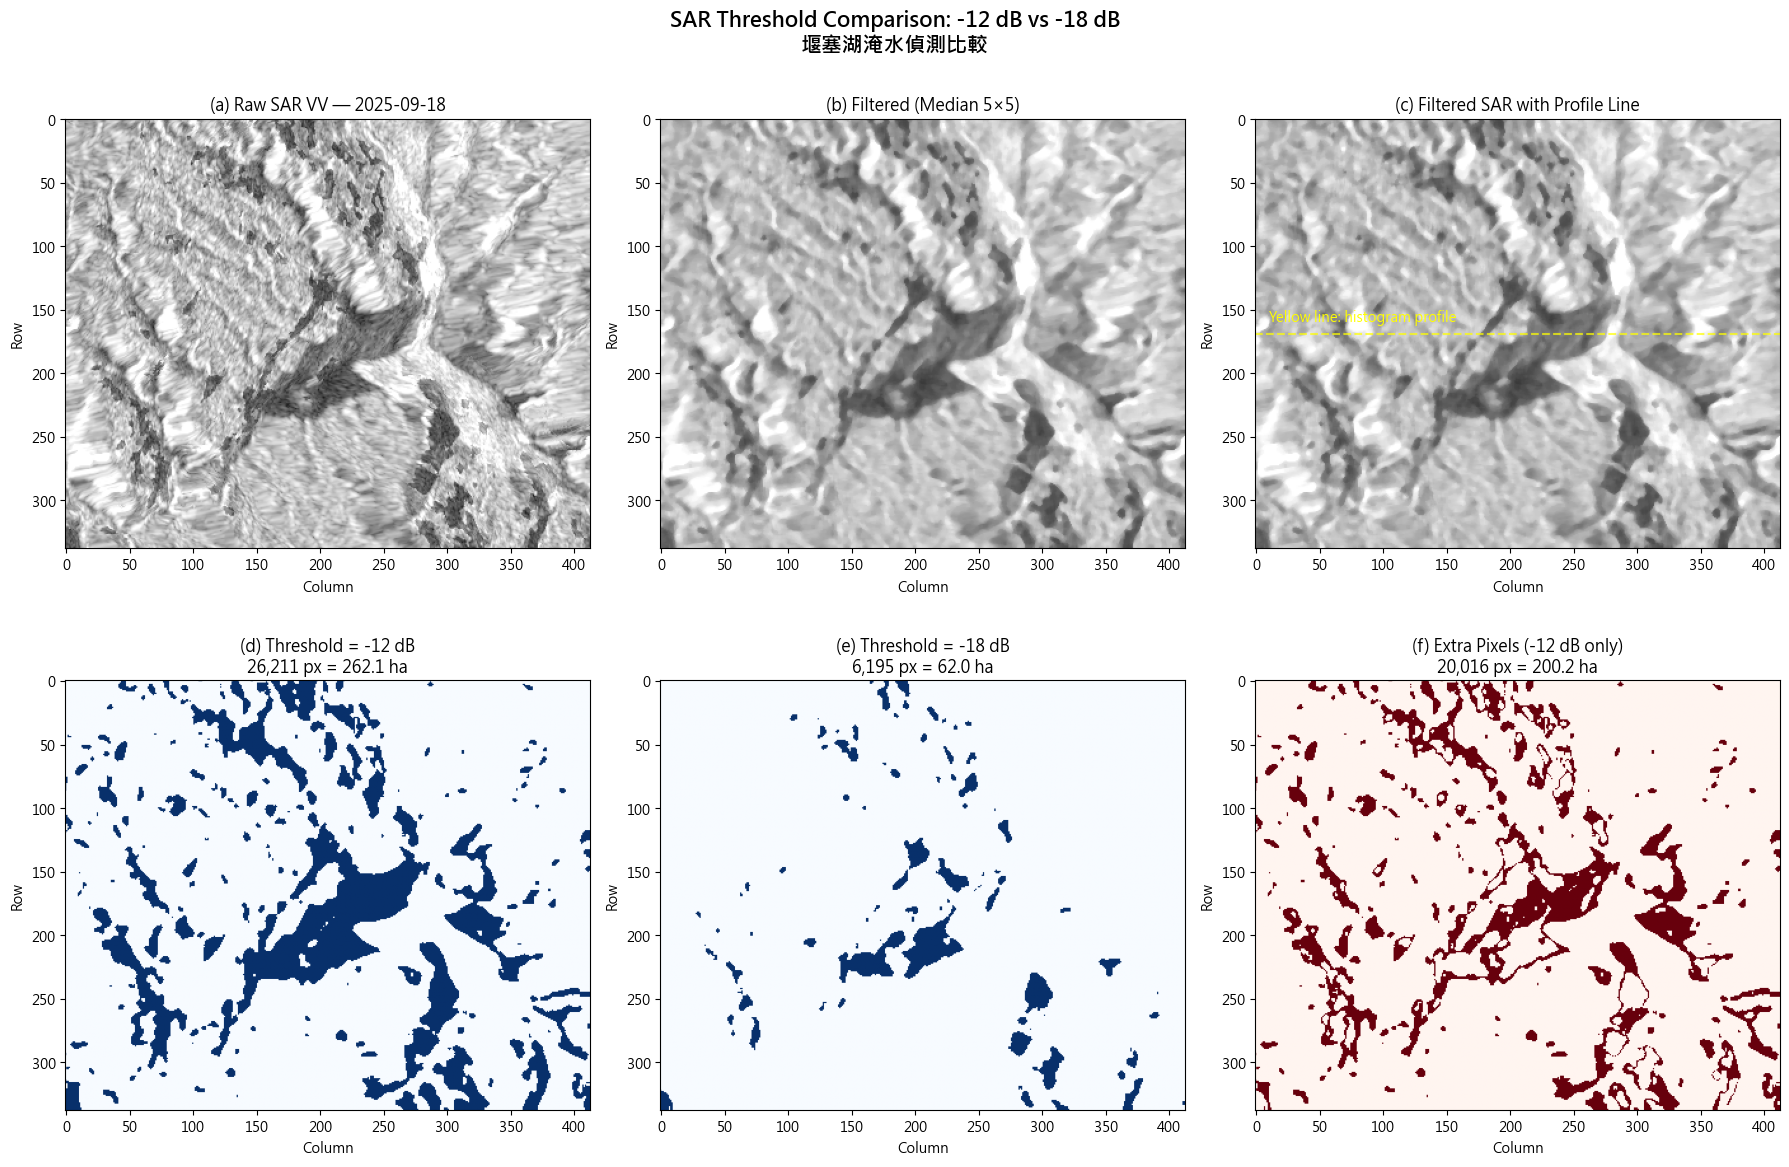

In [8]:
# Visualization: Side-by-side Comparison (similar to Week10 Cell 9)
# ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: Raw SAR and filtered versions
axes[0,0].imshow(vv_post_db, cmap='gray', vmin=-30, vmax=0)
axes[0,0].set_title(f'(a) Raw SAR VV — {post_item.properties["datetime"][:10]}')

axes[0,1].imshow(sar_filtered, cmap='gray', vmin=-30, vmax=0)
axes[0,1].set_title('(b) Filtered (Median 5×5)')

# Histogram overlay on filtered image
axes[0,2].imshow(sar_filtered, cmap='gray', vmin=-30, vmax=0)
axes[0,2].axhline(y=sar_filtered.shape[0]//2, color='yellow', linestyle='--', alpha=0.7)
axes[0,2].text(10, sar_filtered.shape[0]//2-10, f'Yellow line: histogram profile', color='yellow', fontsize=10)
axes[0,2].set_title('(c) Filtered SAR with Profile Line')

# Row 2: Threshold comparisons
axes[1,0].imshow(mask_loose, cmap='Blues', vmin=0, vmax=1)
axes[1,0].set_title(f'(d) Threshold = {THRESHOLD_LOOSE} dB\n{loose_count:,} px = {loose_area:.1f} ha')

axes[1,1].imshow(mask_strict, cmap='Blues', vmin=0, vmax=1)
axes[1,1].set_title(f'(e) Threshold = {THRESHOLD_STRICT} dB\n{strict_count:,} px = {strict_area:.1f} ha')

# Difference map
diff_mask = mask_loose - mask_strict  # Pixels detected by -12 but not -18
axes[1,2].imshow(diff_mask, cmap='Reds', vmin=0, vmax=1)
axes[1,2].set_title(f'(f) Extra Pixels (-12 dB only)\n{np.sum(diff_mask):,} px = {np.sum(diff_mask)*px_area_ha:.1f} ha')

for ax in axes.flat:
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')

plt.suptitle(f'SAR Threshold Comparison: {THRESHOLD_LOOSE} dB vs {THRESHOLD_STRICT} dB\n堰塞湖淹水偵測比較',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/SAR_threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Summary Statistics and Analysis
# ──────────────────────────────────────────────────────────────────
print('=' * 70)
print('SAR THRESHOLD COMPARISON REPORT')
print('=' * 70)
print(f'  Study Area: 馬太鞍溪堰塞湖')
print(f'  SAR Date: {post_item.properties["datetime"][:10]}')
print(f'  Orbit: {post_item.properties.get("sat:orbit_state", "?")}')
print(f'  Processing: Median filter (5×5) + Direct threshold')
print('-' * 70)

print(f'\nTHRESHOLD COMPARISON:')
print(f'  {THRESHOLD_LOOSE} dB (loose):  {loose_count:,} px = {loose_area:.1f} ha')
print(f'  {THRESHOLD_STRICT} dB (strict): {strict_count:,} px = {strict_area:.1f} ha')
print(f'  Difference: {loose_count - strict_count:,} px = {(loose_count - strict_count) * px_area_ha:.1f} ha')
print(f'  NCDR Reference: ~80 ha')

print(f'\nACCURACY ASSESSMENT:')
if abs(loose_area - 80) < abs(strict_area - 80):
    print(f'  ✓ {THRESHOLD_LOOSE} dB closer to reference (diff: {abs(loose_area - 80):.1f} ha)')
else:
    print(f'  ✓ {THRESHOLD_STRICT} dB closer to reference (diff: {abs(strict_area - 80):.1f} ha)')

print(f'\nTHRESHOLD CHARACTERISTICS:')
print(f'  {THRESHOLD_LOOSE} dB:')
print(f'    - Pros: Higher detection rate, less false negatives')
print(f'    - Cons: More false positives, includes rough surfaces')
print(f'  {THRESHOLD_STRICT} dB:')
print(f'    - Pros: Higher precision, cleaner water mask')
print(f'    - Cons: May miss turbid or wind-affected water')

# Calculate mean dB values for detected pixels
loose_pixels = sar_filtered[mask_loose == 1]
strict_pixels = sar_filtered[mask_strict == 1]

print(f'\nDETECTED PIXELS STATISTICS:')
print(f'  {THRESHOLD_LOOSE} dB: mean = {np.nanmean(loose_pixels):.1f} dB, std = {np.nanstd(loose_pixels):.1f} dB')
print(f'  {THRESHOLD_STRICT} dB: mean = {np.nanmean(strict_pixels):.1f} dB, std = {np.nanstd(strict_pixels):.1f} dB')

print('=' * 70)
print('RECOMMENDATION:')
if loose_area > 100:
    print(f'  → {THRESHOLD_LOOSE} dB may be too inclusive (overestimation)')
elif strict_area < 50:
    print(f'  → {THRESHOLD_STRICT} dB may be too strict (underestimation)')
else:
    print(f'  → Both thresholds reasonable; choice depends on application')
print(f'  → For early warning: Use looser threshold + morphological cleaning')
print(f'  → For precise mapping: Use stricter threshold + validation')
print('=' * 70)

SAR THRESHOLD COMPARISON REPORT
  Study Area: 馬太鞍溪堰塞湖
  SAR Date: 2025-09-18
  Orbit: ascending
  Processing: Median filter (5×5) + Direct threshold
----------------------------------------------------------------------

THRESHOLD COMPARISON:
  -12 dB (loose):  26,211 px = 262.1 ha
  -18 dB (strict): 6,195 px = 62.0 ha
  Difference: 20,016 px = 200.2 ha
  NCDR Reference: ~80 ha

ACCURACY ASSESSMENT:
  ✓ -18 dB closer to reference (diff: 18.0 ha)

THRESHOLD CHARACTERISTICS:
  -12 dB:
    - Pros: Higher detection rate, less false negatives
    - Cons: More false positives, includes rough surfaces
  -18 dB:
    - Pros: Higher precision, cleaner water mask
    - Cons: May miss turbid or wind-affected water

DETECTED PIXELS STATISTICS:
  -12 dB: mean = -15.7 dB, std = 2.6 dB
  -18 dB: mean = -19.5 dB, std = 1.0 dB
RECOMMENDATION:
  → -12 dB may be too inclusive (overestimation)
  → For early warning: Use looser threshold + morphological cleaning
  → For precise mapping: Use stricter thresho

## Conclusions / 結論

### Key Findings:
1. **-12 dB**: Higher detection but more noise/surface scattering
2. **-18 dB**: Cleaner detection but may miss some water bodies
3. **Log histogram**: Shows clear separation between water and non-water distributions

### Practical Recommendations:
- **Early warning systems**: Use -12 dB with morphological cleaning
- **Precise mapping**: Use -18 dB with optical validation
- **Operational use**: Combine both thresholds for confidence mapping

### Next Steps:
- Add morphological cleaning comparison
- Test with different speckle filter sizes
- Validate against ground truth data